In [1]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt

In [2]:
env = gym.make("Taxi-v3")

Initialize Q-table

In [3]:
state_size = env.observation_space.n
action_size = env.action_space.n

In [4]:
Q = np.zeros((state_size, action_size))

In [5]:
alpha = 0.1        # Learning rate
gamma = 0.99       # Discount factor
epsilon = 1.0      # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 5000
max_steps = 100

In [6]:
def epsilon_greedy_probs(state):
    probs = np.ones(action_size) * (epsilon / action_size)
    best_action = np.argmax(Q[state])
    probs[best_action] += 1 - epsilon
    return probs

Training

In [7]:
episode_rewards = []
window = 20

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(max_steps):
        probs = epsilon_greedy_probs(state)
        action = np.random.choice(np.arange(action_size), p=probs)
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        next_probs = epsilon_greedy_probs(next_state)
        expected_Q = np.dot(Q[next_state], next_probs)
        
        td_target = reward + gamma * expected_Q
        Q[state][action] += alpha * (td_target - Q[state][action])
        
        state = next_state
        total_reward += reward
        
        if done:
            break
    
    episode_rewards.append(total_reward)
    if len(episode_rewards) >= window:
        moving_avg = np.mean(episode_rewards[-window:])
  
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Expected SARSA training complete.")

Expected SARSA training complete.


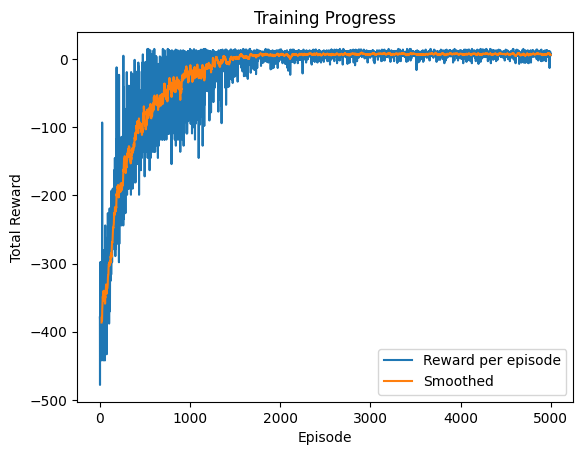

In [8]:
plt.plot(episode_rewards, label="Reward per episode")
window = 20
smoothed = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode='valid'
)
plt.plot(range(window-1, len(episode_rewards)), smoothed, label="Smoothed")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Progress")
plt.legend()
plt.show()

In [9]:
print("Average reward (last 100):", np.mean(episode_rewards[-100:]))

Average reward (last 100): 7.08


In [10]:
policy = np.argmax(Q, axis=1)
print(policy[:20])

[0 4 4 4 0 0 0 2 0 0 0 0 2 0 2 0 5 0 0 0]


Test trained agent

In [11]:
epsilon = 0.0

test_rewards = []

for _ in range(100):
    state, _ = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = np.argmax(Q[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
    
    test_rewards.append(total_reward)

print("Evaluation average:", np.mean(test_rewards))

Evaluation average: 7.91


In [12]:
import time

env = gym.make("Taxi-v3", render_mode="human")

state, _ = env.reset()
done = False
total_reward = 0

while not done:
    action = np.argmax(Q[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward
    time.sleep(0.5)   # Slow it down so you can see it

print("Total reward from trained agent:", total_reward)
env.close()

Total reward from trained agent: 11
